**El primer paso es realizar un análisis exploratiorio, es importante conocer nuestros datos para saber qué podemos hacer con ellos.**

En primer lugar, hay que cargar los datos al entorno de colab para poder cargarlos depués. Las siguientes líneas muestran un botón para abrir un explroador y cargar los datos, aunque es posible realizar esto desde la interfaz de usuario a través del ícono de carpeta.
Esto no es necesario cuando trabajas con IDE locales, solo debes conocer bien la ruta a tus datos o, mejor aún, tenerlos en el mismo directorio.

In [4]:
from google.colab import files
uploaded = files.upload()

Saving full.csv to full.csv


Las siguientes líneas cargan la librería que se utilizará, para posteriormente indicarle a python que lea nuestros datos para que trabajemos con ellos. Por eso es importante conocer el tipo y estructura de los datos
El archivo es csv, por eso se utiiza pd.read_csv.
Primero está el nombre del archivo (aunque, si no está en el mismo directorio, será necesario especificar la ruta hacia él)
En segundo lugar, se le indica a python que ignore las líneas que inician con # (ya que los datos tienen un encabezado cuyas líneas comienzan así). De lo contrario, obtendremos un error.
Cada pieza de información está separada por comas, pero encerrada entre comillas, esto se indica en el tercer argumento.
Por último, se indica qu si algo comienza con un espacio, este espacio se ignore y prosiga.
Todo lo anterior se escribió a partir de conocer los datos y al solucionar errores que surgían al ejecutar.

In [5]:
import pandas as pd
datos = pd.read_csv("full.csv", comment='#', quotechar='"', skipinitialspace=True)

A continuación, se observan las primeras filas de las columnas (con .head()) y se detecta el tipo de cada una (con .dtypes). Luego, con describe, aparece un resumen estadístico de los datos. En este caso se trabaja con variables cualitativas, por lo que añade el argumento include = "all" para que se presente información sobre este tipo de datos

In [6]:
print(datos.head())

        first_seen_utc   ioc_id                          ioc_value ioc_type  \
0  2026-08-17 22:24:50  1878680               faustformelsystem.ch   domain   
1  2026-08-17 22:15:44  1878677  http://kupzovo.shop:7567/accounts      url   
2  2026-08-17 21:31:04  1878666             https://bolerkas.shop/      url   
3  2026-08-17 21:31:03  1878665              https://bolerkas.sbs/      url   
4  2026-08-17 21:14:28  1878663          designtrustventures.co.ke   domain   

        threat_type    fk_malware malware_alias malware_printable  \
0  payload_delivery  js.clearfake           NaN         ClearFake   
1         botnet_cc     win.remus           NaN             Remus   
2  payload_delivery       unknown           NaN   Unknown malware   
3  payload_delivery       unknown           NaN   Unknown malware   
4  payload_delivery  js.clearfake           NaN         ClearFake   

  last_seen_utc  confidence_level  is_compromised  \
0           NaN                90           False   
1   

In [7]:
print(datos.dtypes)

first_seen_utc       object
ioc_id                int64
ioc_value            object
ioc_type             object
threat_type          object
fk_malware           object
malware_alias        object
malware_printable    object
last_seen_utc        object
confidence_level      int64
is_compromised         bool
reference            object
tags                 object
anonymous             int64
reporter             object
dtype: object


La columna confidence level nos dice qué tan probable es que un IOC sea una amenaza. No nos interesan demasiado aquellas sin una probabilidad real, así que, revisando el mínimo, existen datos con un 0 de confianza.
Solo nos interesarán aquellos quetengan más de la mitad de probabilidades de ser una amenaza

In [8]:
print(datos['confidence_level'].min())

0


In [9]:
datos = datos[datos['confidence_level']>50]

In [10]:
print(datos.describe(include="all"))

             first_seen_utc        ioc_id                     ioc_value  \
count                 95355  9.535500e+04                         95355   
unique                66759           NaN                         94509   
top     2026-03-03 23:00:21           NaN  api-ext.bixbitemarketing.com   
freq                     29           NaN                             3   
mean                    NaN  1.782507e+06                           NaN   
std                     NaN  1.592274e+05                           NaN   
min                     NaN  5.300000e+01                           NaN   
25%                     NaN  1.771046e+06                           NaN   
50%                     NaN  1.806753e+06                           NaN   
75%                     NaN  1.850316e+06                           NaN   
max                     NaN  1.878680e+06                           NaN   

       ioc_type       threat_type    fk_malware  \
count     95355             95355         95355 

Fue posible detectar que dos de las columnas eran fechas, así que se convierten a dicho formato.
Hay que destacar que previamente se conocieros los nombres de las columnas. Al escribir nombre_conjunto["columna"], se indica que el código se va a ejecutar solo sobre dicha columna. Aquí le estamos diciendo, cambia la columna "first_seen_utc" del conjunto datos por la conversión a fecha de la columna "first_seen_utc" del conjunto datos, e ignora los errores.

In [11]:
datos["first_seen_utc"] = pd.to_datetime(datos['first_seen_utc'], errors='coerce')
datos["last_seen_utc"] = pd.to_datetime(datos['last_seen_utc'], errors='coerce')

Si imprimimos el tipo de datos, el tipo para estas columnas cambió a datetime

In [12]:
print(datos.dtypes)

first_seen_utc       datetime64[ns]
ioc_id                        int64
ioc_value                    object
ioc_type                     object
threat_type                  object
fk_malware                   object
malware_alias                object
malware_printable            object
last_seen_utc        datetime64[ns]
confidence_level              int64
is_compromised                 bool
reference                    object
tags                         object
anonymous                     int64
reporter                     object
dtype: object


Para conocer un poco más de los datos y entender las columnas, observamos cuáles son nuestra primera y última fechas. Destaca el hecho de que los primeros registros datan de 2020. La fecha en que fue observado por primera vez un IOC se mantiene. Si quisiéramos hacer una serie de tiempo con las amenazas registradas en los últimos 6 meses, nos interesa la columna last_seen_utc

In [13]:
print("La fecha más antigua registrada es:", datos["first_seen_utc"].min())
print("La fecha más reciente registrada es:", datos["first_seen_utc"].max())

La fecha más antigua registrada es: 2020-12-14 08:44:34
La fecha más reciente registrada es: 2026-08-17 22:24:50


Además, es necesario identificar los datos nulos (ausentes), para saber qué se puede hacer con ellos. Hay muchos nulos en last_seen_utc.

In [14]:
datos.isnull().sum()

,0
first_seen_utc,0
ioc_id,0
ioc_value,0
ioc_type,0
threat_type,0
fk_malware,0
malware_alias,72952
malware_printable,0
last_seen_utc,51344
confidence_level,0


Apartir de nuestro análisis principal, sabemos que estos nulos se deben a que, si la fecha de primera vez observados es la única vez, no se agrega a last_seen_utc. Esto se soluciona fácilmente rellenando los nulos en last_seen_utc con la información de first_seen_utc.
Se está creando una nueva columna y, aunque la estructura es igual a reasignar columnas existentes, la diferencia es, precisamente, que no existían y se crearán de cero. Usamos el formato conjunto["nueva_columna] = ...

In [15]:
datos["secuencia"] = datos["last_seen_utc"].fillna(datos["first_seen_utc"])

A partir de ello podemos extraer datos como la fecha, el día de la semana y la hora de la amenaza.

In [16]:
datos["dia"] = (datos["secuencia"]).dt.date
datos["dia_week"] = (datos["secuencia"]).dt.day_of_week
datos["hora"] = (datos["secuencia"]).dt.hour

Para poder empezar a generar gráficos con los datos, es necesario agruparlos, para que solo utilicemos la clase y el número de ocurrencias. Utilizamos .value_counts() para que precisamente realice esta suma.

In [17]:
agrupados = datos['threat_type'].value_counts().reset_index()
agrupados.columns = ['threat_type', 'cantidad_detectada']

Para graficar se importa la librería matplotlib.
Un gráfico de barras básico se genera con el comando plt.bar(datos_ejex, datos_ejey).En este caso se utilizan las columnas del tipo de amenaza y el conteo. Es posible agregar elemeentos al gráfico, para ello es posible consultar la documentación de matplotlib.

/tmp/ipykernel_2264/2605997826.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(agrupados["threat_type"],rotation=45, ha='right')


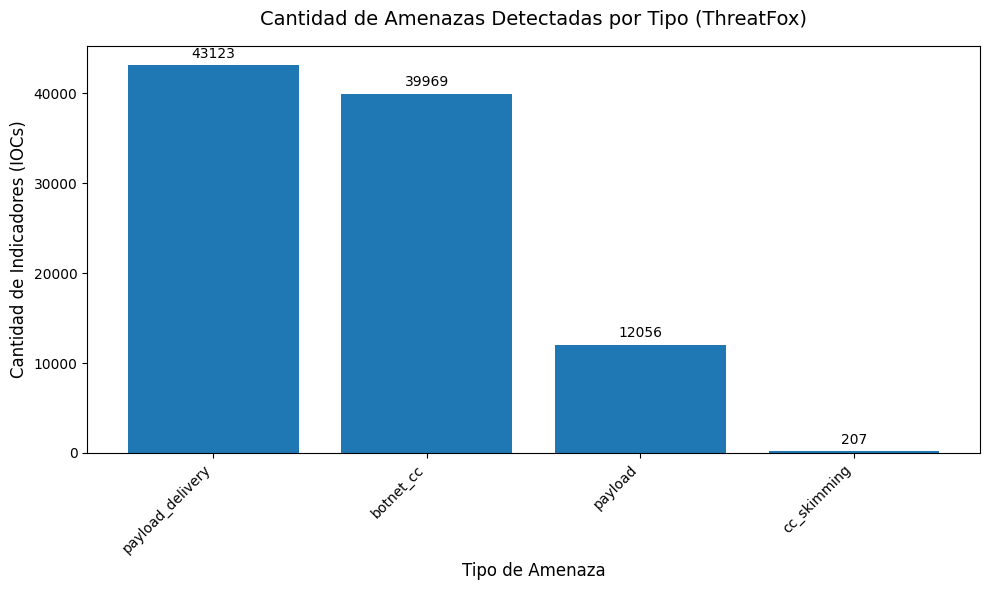

In [19]:
import matplotlib.pyplot as plt

fig1, ax1 = plt.subplots(figsize=(10, 6))
barras = ax1.bar(agrupados["threat_type"], agrupados["cantidad_detectada"])

ax1.set_title("Cantidad de Amenazas Detectadas por Tipo (ThreatFox)", fontsize=14, pad=15)
ax1.set_xlabel("Tipo de Amenaza", fontsize=12)
ax1.set_ylabel("Cantidad de Indicadores (IOCs)", fontsize=12)
ax1.set_xticklabels(agrupados["threat_type"],rotation=45, ha='right')
ax1.bar_label(barras, padding=3, fontsize=10, color='black')
fig1.tight_layout()

fig1.savefig("grafico_barras.png", bbox_inches = 'tight', transparent = True)

También se puede realizar un gráfico de barras, cuando queremos saber qué porcentaje de un total representa cada categoría. Es importante evitar incluir demasiadas categorías, pues se podría obtener un gráfico difícil de interpretar.
La sintaxis es plt.pie(x = datos_para_porcentajes, labels = etiquetas)

In [ ]:
fig2,ax2 = plt.subplots(figsize=(10, 6))
ax2.pie(x=agrupados['cantidad_detectada'], labels=agrupados["threat_type"], autopct='%1.1f%%')
ax2.set_title("Top 5 de Amenazas Detectadas", fontsize=14, pad=15)
fig2.savefig("grafico_pastel.png", bbox_inches='tight', transparent=True)

Después se ordenan los datos por fecha para realmente tener una serie de tiempo que se pueda graficar y analizar.

In [ ]:
totales_dia = datos.groupby("dia").size().reset_index(name="count")

Incluso imprimiendo los datos ordenados de mayor a menor podemos obtener información valiosa, como el día con mayores registros.

In [ ]:
print(totales_dia.head())

También se pueden generar gráficos de líneas que permiten detectar la evolución de una variable (el número de amenazas) en el tiempo, para eso se usa pl.plot(datos_ejex, datos_ejey)

In [ ]:
fig3,ax3 = plt.subplots(figsize=(10, 6))
ax3.plot(totales_dia["dia"], totales_dia['count'], marker='.', color='firebrick')
ax3.set_title("Cantidad de amenazas por día")
ax3.set_xlabel("Fecha")
ax3.set_ylabel("Registros de IOC")
ax3.grid(True, linestyle='--', alpha=0.7)

fig3.savefig("grafico_lineas.png", bbox_inches = 'tight', transparent = True)

Solo porque estamos en colab tenemos que descargar los archivos a nuestra computadora, esto mediante files.download()

In [ ]:
files.download("grafico_barras.png")
files.download("grafico_lineas.png")
files.download("grafico_pastel.png")

In [ ]:
cols = ["ioc_type", "threat_type"]
datos[cols] = datos[cols].astype('category')
print(datos.describe(include=['category']))

In [ ]:
print(datos.describe(include='all'))